# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych

In [2]:
k = 2.0
n_replicas = 3
n_samples = 4
swap_algorithm = {
	"analytical" : False,
	"swap_towards_k" : False,
	"parallel": True,
	"even": [90, 70, 50, 30],
	"odd": [80, 60, 40, 20],
	"debug" : True
}

# Composed Dataset

p_1.50 (x_2.00) 
---------------
p_1.50 (x_1.50)
p_2.00 (x_1.50) 
---------------
p_2.00 (x_2.00)


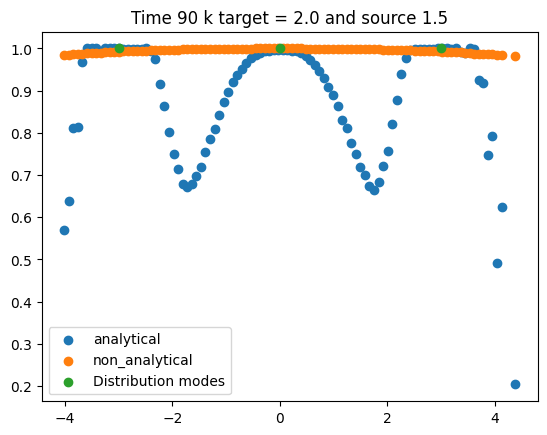

Time 90 swap btwn source 1.50 and target 2.00 accept 1.00 
p_1.00 (x_1.50) 
---------------
p_1.00 (x_1.00)
p_1.50 (x_1.00) 
---------------
p_1.50 (x_1.50)


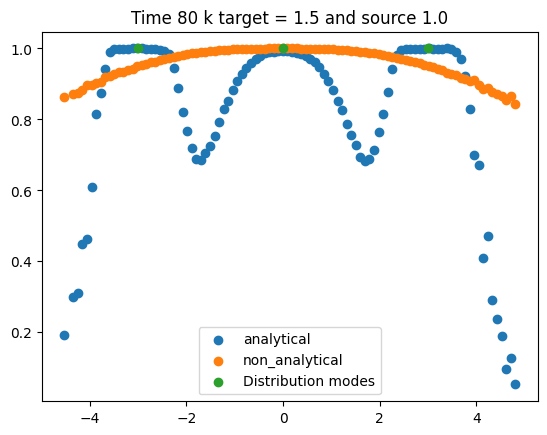

Time 80 swap btwn source 1.00 and target 1.50 accept 1.00 
p_1.50 (x_2.00) 
---------------
p_1.50 (x_1.50)
p_2.00 (x_1.50) 
---------------
p_2.00 (x_2.00)


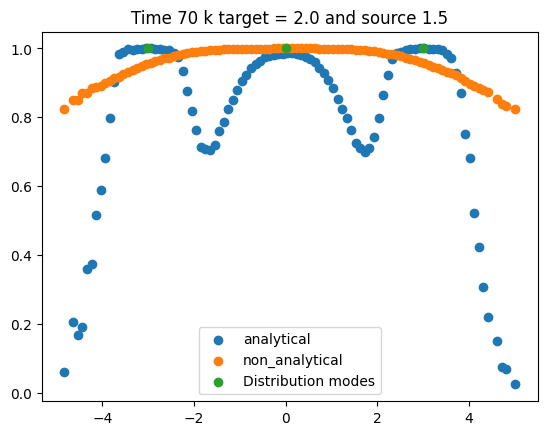

Time 70 swap btwn source 1.50 and target 2.00 accept 0.99 
p_1.00 (x_1.50) 
---------------
p_1.00 (x_1.00)
p_1.50 (x_1.00) 
---------------
p_1.50 (x_1.50)


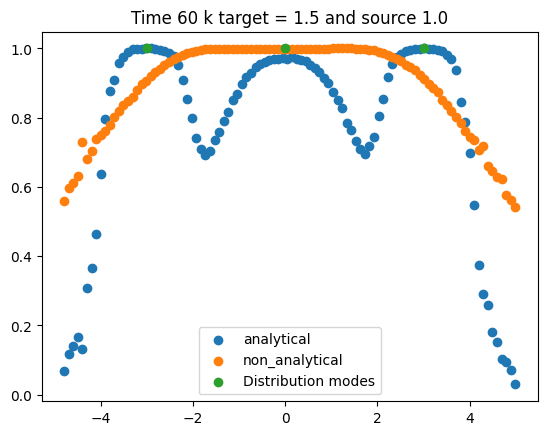

Time 60 swap btwn source 1.00 and target 1.50 accept 0.99 
p_1.50 (x_2.00) 
---------------
p_1.50 (x_1.50)
p_2.00 (x_1.50) 
---------------
p_2.00 (x_2.00)


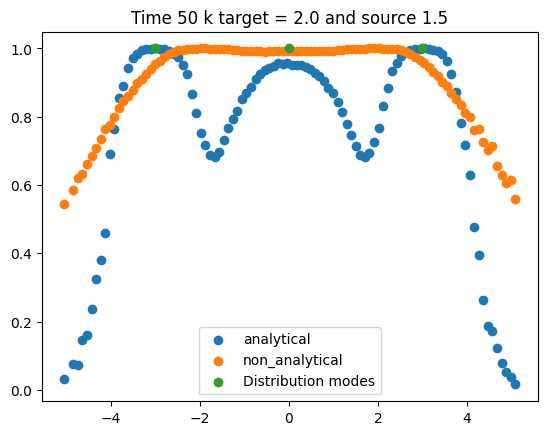

Time 50 swap btwn source 1.50 and target 2.00 accept 0.99 
p_1.00 (x_1.50) 
---------------
p_1.00 (x_1.00)
p_1.50 (x_1.00) 
---------------
p_1.50 (x_1.50)


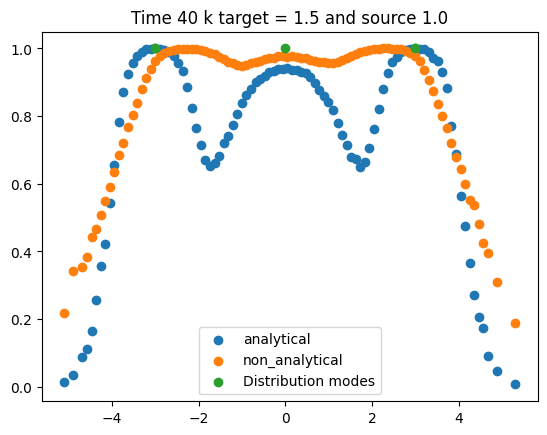

Time 40 swap btwn source 1.00 and target 1.50 accept 0.97 
p_1.50 (x_2.00) 
---------------
p_1.50 (x_1.50)
p_2.00 (x_1.50) 
---------------
p_2.00 (x_2.00)


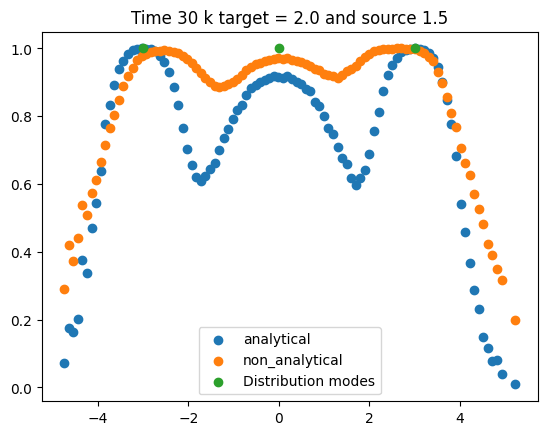

Time 30 swap btwn source 1.50 and target 2.00 accept 0.96 
p_1.00 (x_1.50) 
---------------
p_1.00 (x_1.00)
p_1.50 (x_1.00) 
---------------
p_1.50 (x_1.50)


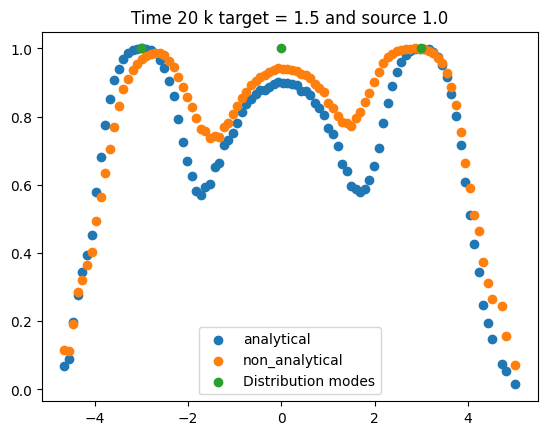

Time 20 swap btwn source 1.00 and target 1.50 accept 0.93 


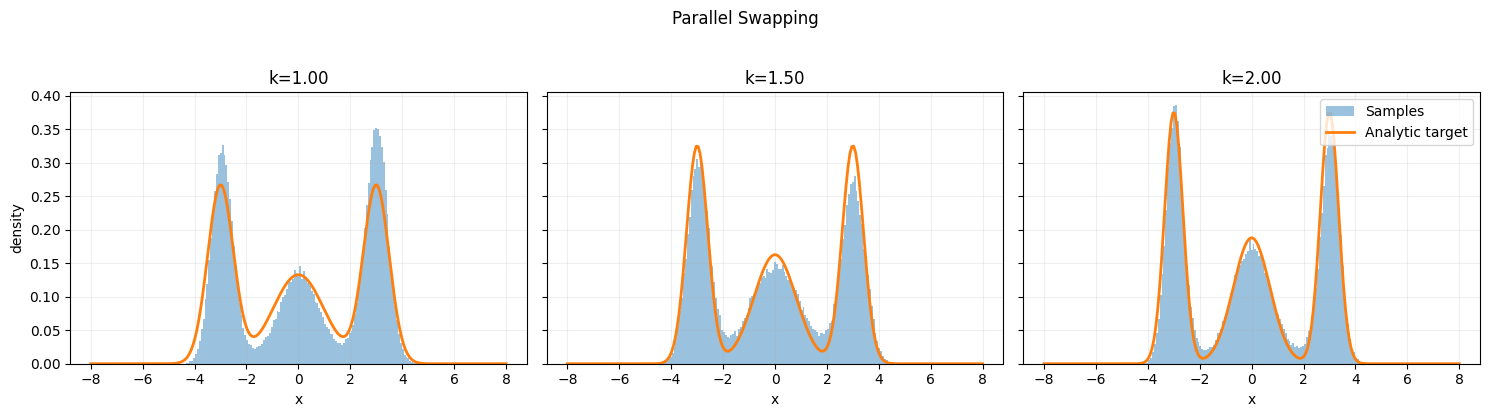

In [3]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	k=k,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=True,
	swap_algorithm=swap_algorithm
)

In [4]:
# _ = plot_temperature_triptych(
# 	dataset_name="composed",
# 	k=k,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

# MNIST Dataset

In [5]:
# _ = plot_temperature_triptych(dataset_name="mnist", sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=True)

In [6]:
# _ = plot_temperature_triptych(dataset_name="mnist", sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=False)

# Other

In [7]:
# import torch
# import matplotlib.pyplot as plt
# import numpy as np

# n_samples=2


# def apply_temperature(x, k=1.0):
#     """x in [0,1]. k>1 sharpens, k<1 flattens."""
#     x = x.clamp(1e-6, 1 - 1e-6)  # avoid log(0)
#     logits = torch.log(x / (1 - x))  # inverse sigmoid
#     logits = logits * k              # scale by temperature
#     return torch.sigmoid(logits)     # back to [0,1]

# x = load_mnist_tensor(train=False, normalize_to_minus1_1=False)

# fig, axes = plt.subplots(n_samples, len(k_range), figsize=(len(k_range) * 2, n_samples*2))

# for row in range(n_samples):
#     for col, k in enumerate(k_range):
#         img = apply_temperature(x[row, 0], k=k)
#         axes[row, col].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
#         axes[row, col].axis("off")
#         if row == 0:
#             axes[row, col].set_title(f"k={k:.2f}")

# plt.tight_layout()
# plt.show()